In [ ]:
#------------------------------------------------
# HEADER
#------------------------------------------------
##
## CASCADE SPECTRA
##
## This file describes the contents of the "Spectra" directory and further 
## below examples of how to load them into Python
##
## Supplementary material for G. Elor, N. Rodd, T. Slatyer, and W. Xue,
## "Model-Independent Indirect Detection Constraints on Hidden Sector Dark
## Matter" (2015)
## Contact: Nick Rodd <nrodd@mit.edu>
##
#------------------------------------------------
##
## Overview
##
## Files within "Spectra" contain the \[Gamma], e^+/e^- and p spectrum of 
## dark matter (DM) annihilations leading to 1-6 step cascades ending in 
## e, mu, tau, b-quark, W, H or gluon final states. A separate .dat file 
## is provided for each type of spectrum and final state. Note all spectra 
## here are calculated using the large hierarchy approximation, which can 
## break down in certain situations. The contents of these files are 
## designed to be similar to the results of M. Cirelli et al., JCAP 1103, 
## 051 (2011), 1012.4515.
##
#------------------------------------------------
##
## Content of files
##
## There are 18 files of the form Cascade_{Final State}_{Spectrum Type}.dat. 
## Each contains 8 columns and 1612 rows (the first row contains the column 
## labels and all others contain numerical values). For all files except 
## gluon final states and the positron spectrum from gammas, the columns are: 
## 1. epsilon_f value; 
## 2. Log10(x), where x=E/Subscript[m, DM]; 
## 3-8. the value of dN/dLog10(x)=ln(10)*x*dN/dx of an n=1 (column 3) up to 
## n=6 (column 8) spectrum at that value of epsilon_f and x. 
## For final state gluons and the positron spectrum from gammas, the columns 
## are:
## 1. m_phi value;
## 2. Log10(x), where x=E/Subscript[m, DM]; 
## 3-8. the value of dN/dLog10(x)=ln(10)*x*dN/dx of an n=1 (column 3) up to 
## n=6 (column 8) spectrum at that value of m_phi and x. 
## The reason for this difference in the case of gluons and the positron 
## spectrum from gammas is that we have to use m_phi values instead of 
## epsilon_f=2m_f/m_phi as for these final states m_f=0 making epsilon_f 
## less useful.
##
#------------------------------------------------
##
## Range of Parameters
##
## Log10(x) ranges from -8.9 to 0 in steps on 0.05, covering the entire range 
## where x^2 dN/dx for each spectra is non-zero. epsilon_f is evaluated at 0.01, 
## 0.03, 0.05, 0.07, 0.1, 0.2, 0.3, 0.4 and 0.5, whilst m_phi is given at 10, 20, 
## 40, 50, 80, 100, 500, 1000 and 2000 GeV.
##
## NB: if using a value of epsilon_f or m_phi not in this list - especially if it
## is outside the range of values provided - it is recommended that linear 
## interpolation be used.
##
## NB: as we are using an interpolating function to determine the spectrum, it can
## occasionally go negative. This is unphysical can cause issues if the Log of the 
## spectrum is being used, and so we set the spectrum to 0 wherever the 
## interpolating function would send it negative.
##
#------------------------------------------------
##
## Brief description of files
##
## Photon Spectra:
## Cascade_{Gam,E,Mu,Tau,B,W,H,G}_gammas.dat - photon spectrum from final state
## {photons, electrons, muons, taus, b-quarks, Ws, Huggs, gluons}
##
## Positron/Electron Spectra:
## Cascade_{Gam,E,Mu,Tau,B,W,H,G}_positrons.dat - positron (or equivalently 
## electron) spectrum from final state {photons, electrons, muons, taus, b-quarks, 
## Ws, Huggs, gluons}
##
## Antiproton Spectra:
## Cascade_{B,W,H,G}_antiprotons.dat - antiproton spectrum from final state {b-quarks,
## Ws, Higgs, gluons}
## NB: electron, muon and tau antiproton spectra are negligible and so not given
##
## Direct Spectra:
## AtProduction_{gammas,positrons,antiprotons}.dat - Direct {photon, positron, 
## antiproton} spectrum as calculated by M. Cirelli et al. These files were produced 
## by those authors, but we provide them here for convenience.
##
#------------------------------------------------
# ENDHEADER
#------------------------------------------------

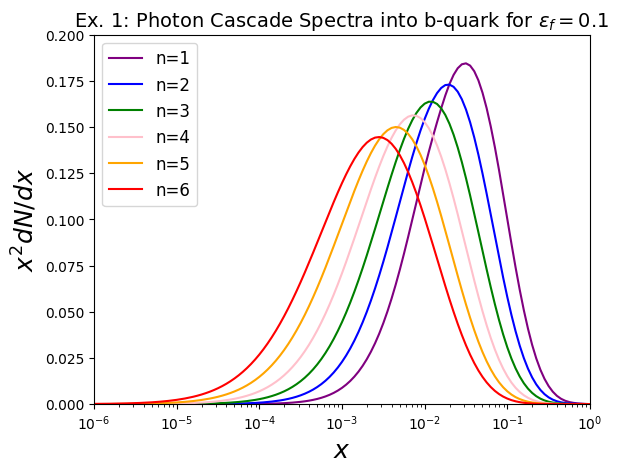

In [14]:
# Import required modules
from scipy.interpolate import interp1d
import numpy as np
from matplotlib import pyplot as plt

#------------------------------------------------
# Example 1
# Photon Cascade Spectra of Final State W Bosons for epsilon_f=0.1
#------------------------------------------------
##
## In this example we load the photon spectrums of 1-6 step cascade DM 
## annihilations terminating in W bosons for epsilon_f=0.1.

filename = '/home/haebarg/GCE-Chi-square-fitting/CascadeSpectra/Spectra/Cascade_B_gammas.dat'

with open(filename) as f:
    lines = (line for line in f if not line.startswith('#'))
    data = np.genfromtxt (lines, names = True ,dtype = None)

epsvals = data["EpsF"]
eps_f = 0.1
index = np.where(np.abs( (epsvals - eps_f) / eps_f) < 1.e-3)
xvals = 10**(data["Log10x"][index])

flux = [data["n"+str(i)][index]/(np.log(10)*xvals) for i in range(1,7)]
loadspec = [interp1d(xvals,flux[i]) for i in range(6)]
def dNdx(x,step):
    fluxval = loadspec[step-1](x)
    if (x>1 or fluxval<0):
        return 0
    else:
        return fluxval

plt.plot(xvals,[x**2*dNdx(x,1) for x in xvals],label='n=1',color='Purple')
plt.plot(xvals,[x**2*dNdx(x,2) for x in xvals],label='n=2',color='Blue')
plt.plot(xvals,[x**2*dNdx(x,3) for x in xvals],label='n=3',color='Green')
plt.plot(xvals,[x**2*dNdx(x,4) for x in xvals],label='n=4',color='Pink')
plt.plot(xvals,[x**2*dNdx(x,5) for x in xvals],label='n=5',color='Orange')
plt.plot(xvals,[x**2*dNdx(x,6) for x in xvals],label='n=6',color='Red')
plt.title('Ex. 1: Photon Cascade Spectra into b-quark for $\epsilon_f=0.1$',fontsize=14)
plt.xscale('log')
plt.xlabel('$x$', fontsize=18)
plt.ylabel('$x^2 dN / dx$', fontsize=18)
plt.ylim([0.0,0.20])
plt.xlim([10**-6,1])
plt.legend(fontsize=12,loc=2)
plt.show()

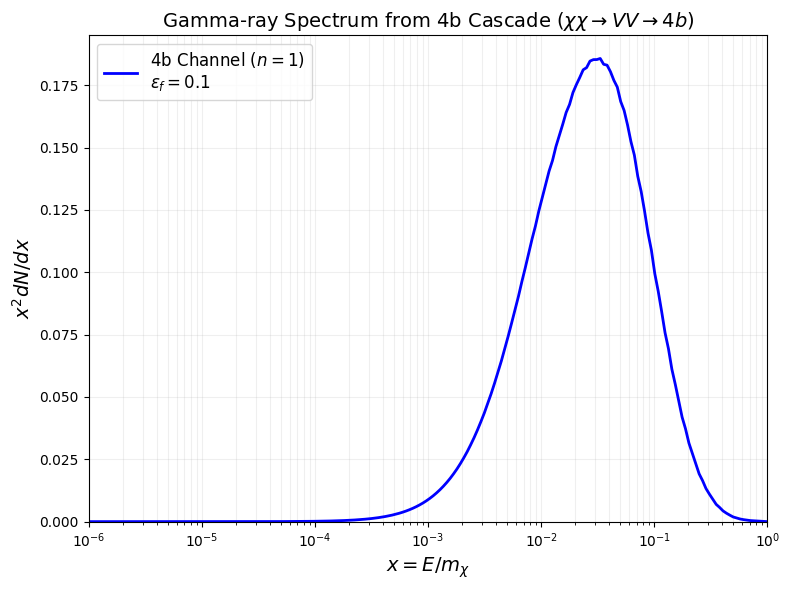

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

filename = '/home/haebarg/GCE-Chi-square-fitting/CascadeSpectra/Spectra/Cascade_B_gammas.dat'
eps_f = 0.1  # Epsilon_f = 2 * m_b / m_V. (0.01, 0.03, 0.05, 0.07, 0.1, 0.2, ...)

try:
    with open(filename, 'r') as f:
        lines = (line for line in f if not line.startswith('#'))
        data = np.genfromtxt(lines, names=True, dtype=None)
except OSError:
    print(f"error: '{filename}' file is not detected, please check the directory")
    raise

epsvals = data["EpsF"]
index = np.where(np.abs((epsvals - eps_f) / eps_f) < 1.e-3)

if len(index[0]) == 0:
    print(f"error: epsilon_f={eps_f} data is not in the file")
    raise ValueError("Invalid epsilon_f")

log10x = data["Log10x"][index]
xvals = 10**log10x
dNdlog10x = data["n1"][index] # n1: 1-step cascade (4-body)
flux = dNdlog10x / (np.log(10) * xvals)
loadspec = interp1d(xvals, flux, kind='linear', fill_value="extrapolate")

def get_dNdx(x):
    if x > 1 or x < 10**-8.9: 
        return 0
    val = loadspec(x)
    return max(0, val)

x_plot = np.logspace(-6, 0, 200)
y_plot = [x**2 * get_dNdx(x) for x in x_plot]

plt.figure(figsize=(8, 6))
plt.plot(x_plot, y_plot, label=f'4b Channel ($n=1$)\n$\epsilon_f={eps_f}$', color='blue', linewidth=2)

plt.title(r'Gamma-ray Spectrum from 4b Cascade ($\chi\chi \to VV \to 4b$)', fontsize=14)
plt.xlabel(r'$x = E / m_{\chi}$', fontsize=14)
plt.ylabel(r'$x^2 dN / dx$', fontsize=14)
plt.xscale('log')
plt.ylim(bottom=0)
plt.xlim([1e-6, 1])
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

Processing: front, 14 bins, Model X (4b)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_14_4b_16yr.png


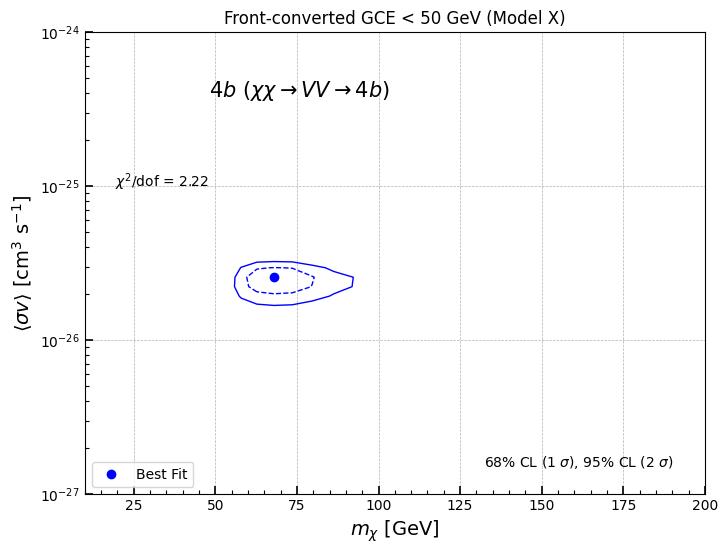

Processing: front, 17 bins, Model X (4b)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_17_4b_16yr.png


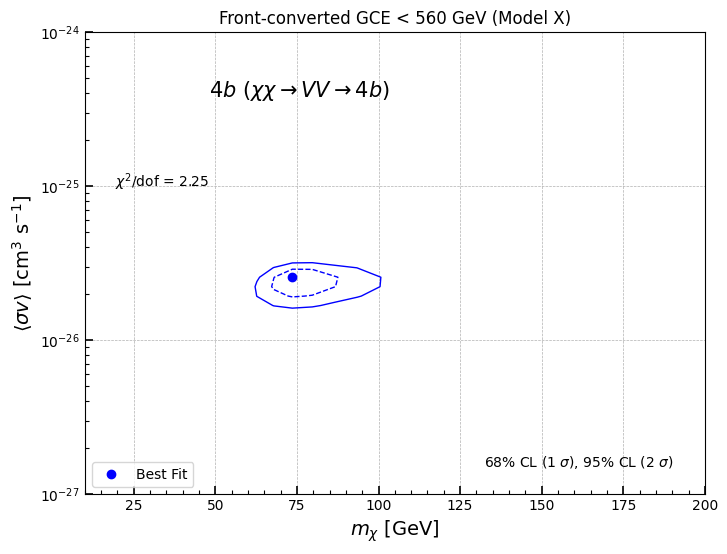

Processing: front_back, 14 bins, Model X (4b)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_14_4b_16yr.png


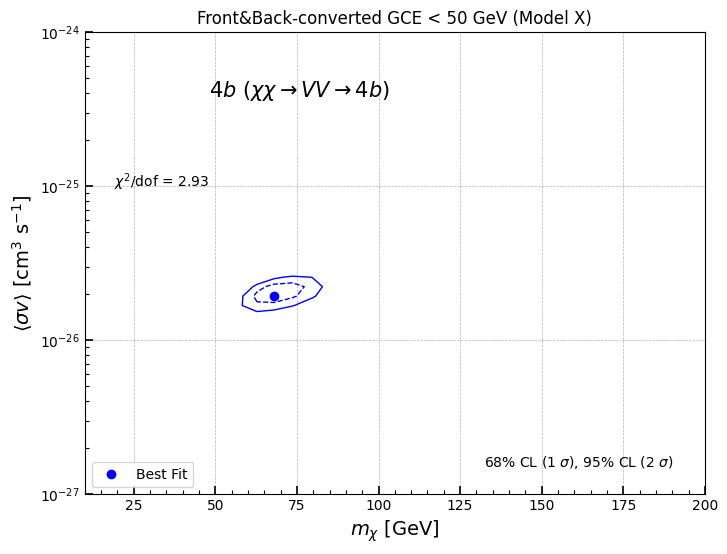

Processing: front_back, 17 bins, Model X (4b)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_17_4b_16yr.png


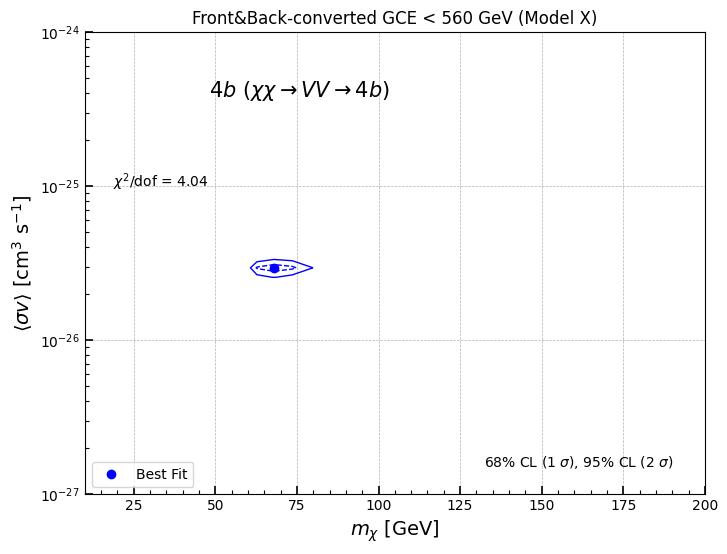

In [ ]:
# Model I Covariance matrix used of 4b (Cascade) case chi-squared contour plot

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
import warnings
import os

def get_cascade_spectrum(mass, channel_file, eps_f=0.01):
    """
    Cascade Spectra 라이브러리에서 4-body 스펙트럼을 로드합니다.
    
    Parameters:
    - mass: 암흑물질 질량 (GeV)
    - channel_file: 파일 이름 (예: 'Cascade_B_gammas.dat')
    - eps_f: Phase space parameter (기본값 0.1)
    
    Returns:
    - energy_axis: 에너지 배열 (GeV)
    - dNdE: 에너지 스펙트럼 (GeV^-1)
    """

    possible_paths = ['./CascadeSpectra/Spectra', './', '/home/haebarg/ipynb/Spectra/']
    full_path = None
    
    for p in possible_paths:
        test_path = os.path.join(p, channel_file)
        if os.path.exists(test_path):
            full_path = test_path
            break
            
    if full_path is None:
        raise FileNotFoundError(f"Cannot find Cascade file: {channel_file}. 'Spectra' 폴더를 확인해주세요.")

    try:
        with open(full_path, 'r') as f:
            lines = (line for line in f if not line.startswith('#'))
            data = np.genfromtxt(lines, names=True, dtype=None)
    except Exception as e:
        print(f"Error loading {full_path}: {e}")
        return None, None

    epsvals = data["EpsF"]
    index = np.where(np.abs((epsvals - eps_f) / eps_f) < 1.e-3)
    
    if len(index[0]) == 0:
        raise ValueError(f"Epsilon_f = {eps_f} not found in file.")

    log10x = data["Log10x"][index]
    x_vals = 10**log10x

    dNdlog10x = data["n1"][index] 
    dNdx = dNdlog10x / (np.log(10) * x_vals)
    
    interp_func = interp1d(x_vals, dNdx, kind='linear', bounds_error=False, fill_value=0.0)
    energy_axis = np.logspace(np.log10(1e-6 * mass), np.log10(mass), 500)
    x_target = energy_axis / mass
    
    dNdx_vals = interp_func(x_target)
    dNdE = dNdx_vals / mass
    dNdE = np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)
    dNdE[dNdE < 0] = 0.0
    
    return energy_axis, dNdE

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
cascade_filename = 'Cascade_B_gammas.dat'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model} ({channel_name})...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                energy_axis, dNdE_vals = get_cascade_spectrum(dm_mass, cascade_filename, eps_f=0.1)
                func_interp = interp1d(energy_axis, dNdE_vals, 
                                     fill_value=0, bounds_error=False, kind='linear')
                
                dNdE_interp = func_interp(emeans)
                model_flux = (emeans**2) * dNdE_interp * (sigma_v/(dm_mass**2)) * J_FACTOR / SR
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)

            chi_square_vec = np.vectorize(chi_square)

            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -24, 50) 
            mass_range = np.logspace(np.log10(10), np.log10(500), 50) 
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            levels = [min_chi2 + 2.30, min_chi2 + 6.18] 

            plt.figure(figsize=(8, 6))
            
            try:
                CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                            levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)

            except:
                print("⚠️ Contour generation failed (level issue potentially).")
                pass

            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2 / dof), 
                transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'$4b$ ($\chi\chi \to VV \to 4b$)', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GCE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X (4b, r=0.3)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_14_4b_r0.3_16yr.png


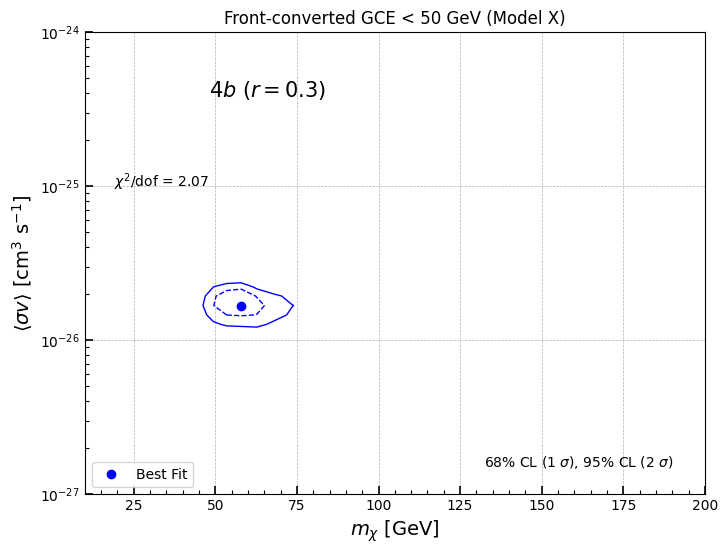

Processing: front, 17 bins, Model X (4b, r=0.3)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_17_4b_r0.3_16yr.png


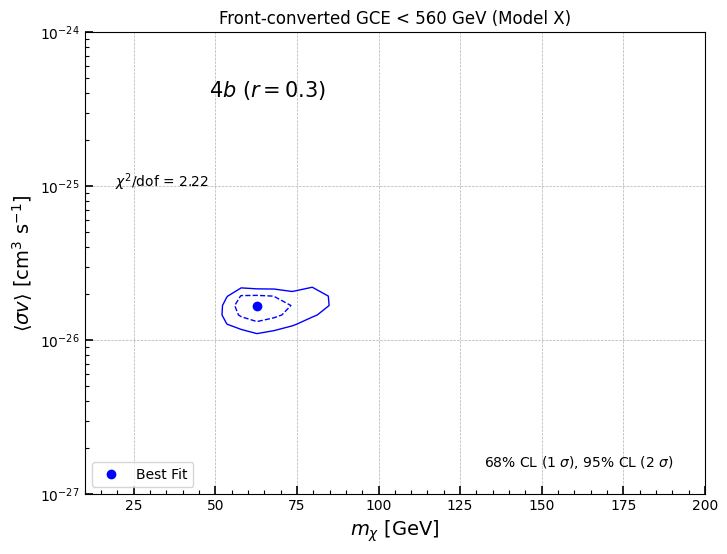

Processing: front_back, 14 bins, Model X (4b, r=0.3)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_14_4b_r0.3_16yr.png


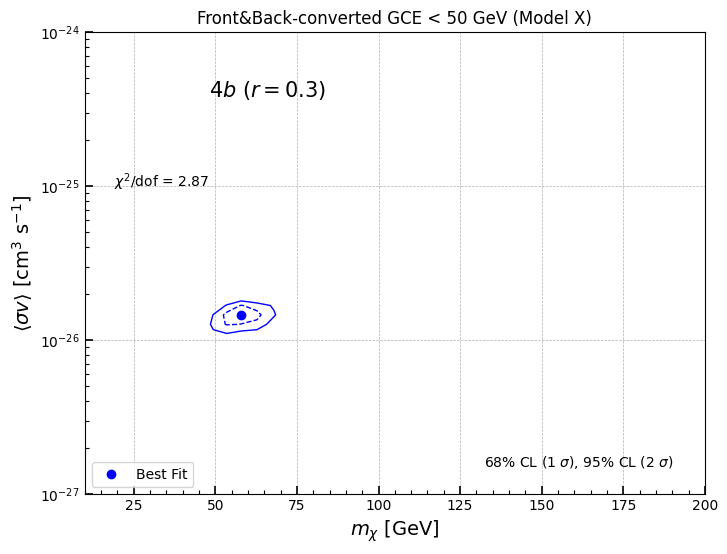

Processing: front_back, 17 bins, Model X (4b, r=0.3)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_17_4b_r0.3_16yr.png


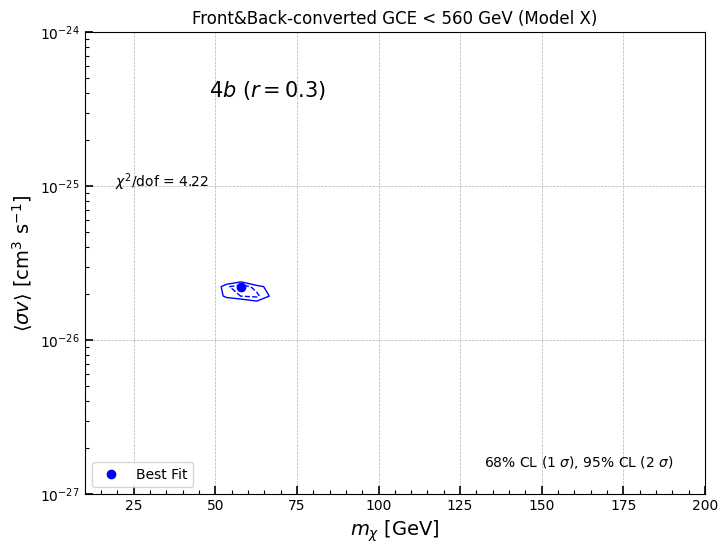

In [ ]:
# Model I Covariance matrix used of 4b (Cascade) case chi-squared contour plot r0.3

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
import warnings
import os

# 🔥 핵심 마법: 파일 데이터를 저장해둘 전역 딕셔너리 (캐시)
_CASCADE_CACHE = {}

def get_cascade_spectrum(mass, channel_file, eps_f=0.01):
    """
    Cascade Spectra 라이브러리에서 4-body 스펙트럼을 로드합니다.
    """
    if channel_file not in _CASCADE_CACHE:
        possible_paths = ['./CascadeSpectra/Spectra', './', '/home/haebarg/ipynb/Spectra/']
        full_path = None
        
        for p in possible_paths:
            test_path = os.path.join(p, channel_file)
            if os.path.exists(test_path):
                full_path = test_path
                break
                
        if full_path is None:
            raise FileNotFoundError(f"Cannot find Cascade file: {channel_file}. 'Spectra' 폴더를 확인해주세요.")

        try:
            with open(full_path, 'r') as f:
                lines = (line for line in f if not line.startswith('#'))
                _CASCADE_CACHE[channel_file] = np.genfromtxt(lines, names=True, dtype=None)
        except Exception as e:
            print(f"Error loading {full_path}: {e}")
            return None, None

    data = _CASCADE_CACHE[channel_file]

    epsvals = data["EpsF"]
    available_eps = np.unique(epsvals)
    closest_eps = available_eps[np.argmin(np.abs(available_eps - eps_f))]
    index = np.where(epsvals == closest_eps)
    
    if len(index[0]) == 0:
        raise ValueError(f"Epsilon_f = {eps_f} not found in file.")

    log10x = data["Log10x"][index]
    x_vals = 10**log10x

    dNdlog10x = data["n1"][index] 
    dNdx = dNdlog10x / (np.log(10) * x_vals)
    
    interp_func = interp1d(x_vals, dNdx, kind='linear', bounds_error=False, fill_value=0.0)
    energy_axis = np.logspace(np.log10(1e-6 * mass), np.log10(mass), 500)
    x_target = energy_axis / mass
    
    dNdx_vals = interp_func(x_target)
    dNdE = dNdx_vals / mass
    dNdE = np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)
    dNdE[dNdE < 0] = 0.0
    
    return energy_axis, dNdE

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
cascade_filename = 'Cascade_B_gammas.dat'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

# =======================================================
# 📌 여기에 r_ratio와 m_b를 정의합니다! (전역 변수로 설정)
# r=0.1 로 바꾸고 싶으시면 여기서 바로 숫자만 고치시면 됩니다.
# =======================================================
r_ratio = 0.3 
m_b = 4.18

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model} ({channel_name}, r={r_ratio})...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                
                # 위에서 정의한 전역 변수를 그대로 가져다 씁니다.
                dynamic_eps_f = (2 * m_b) / (r_ratio * dm_mass)
                
                energy_axis, dNdE_vals = get_cascade_spectrum(dm_mass, cascade_filename, eps_f=dynamic_eps_f)
                
                func_interp = interp1d(energy_axis, dNdE_vals, 
                                     fill_value=0, bounds_error=False, kind='linear')
                
                dNdE_interp = func_interp(emeans)
                model_flux = (emeans**2) * dNdE_interp * (sigma_v/(dm_mass**2)) * J_FACTOR / SR
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)

            chi_square_vec = np.vectorize(chi_square)

            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -24, 50) 
            mass_range = np.logspace(np.log10(10), np.log10(500), 50) 
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            levels = [min_chi2 + 2.30, min_chi2 + 6.18] 

            plt.figure(figsize=(8, 6))
            
            try:
                CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                            levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)

            except:
                print("⚠️ Contour generation failed (level issue potentially).")
                pass

            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2 / dof), 
                transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'$4b$ ($r={}$)'.format(r_ratio), transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GCE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_r{r_ratio}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X (4b, r=0.1)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_14_4b_r0.1_16yr.png


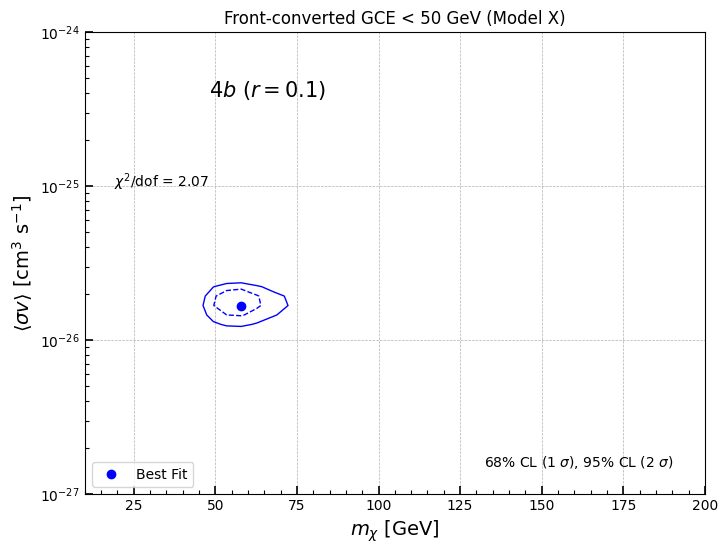

Processing: front, 17 bins, Model X (4b, r=0.1)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_17_4b_r0.1_16yr.png


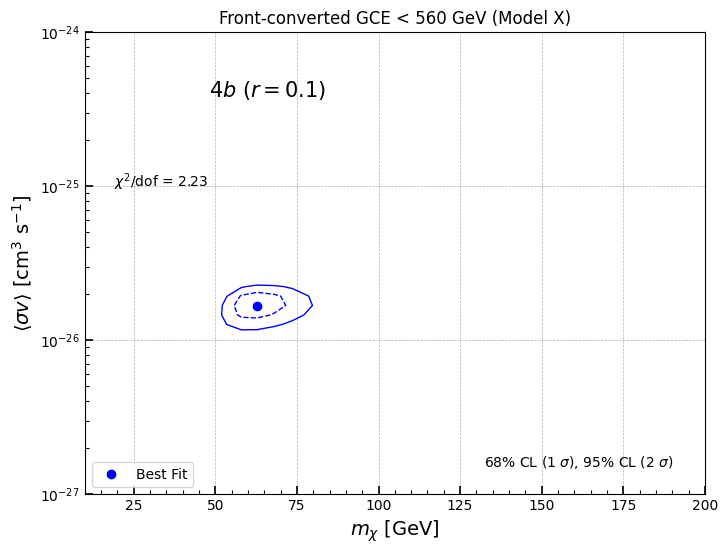

Processing: front_back, 14 bins, Model X (4b, r=0.1)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_14_4b_r0.1_16yr.png


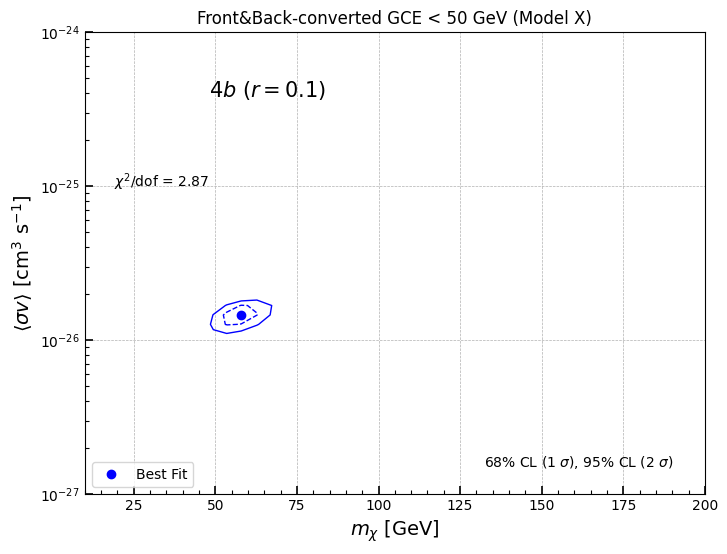

Processing: front_back, 17 bins, Model X (4b, r=0.1)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_17_4b_r0.1_16yr.png


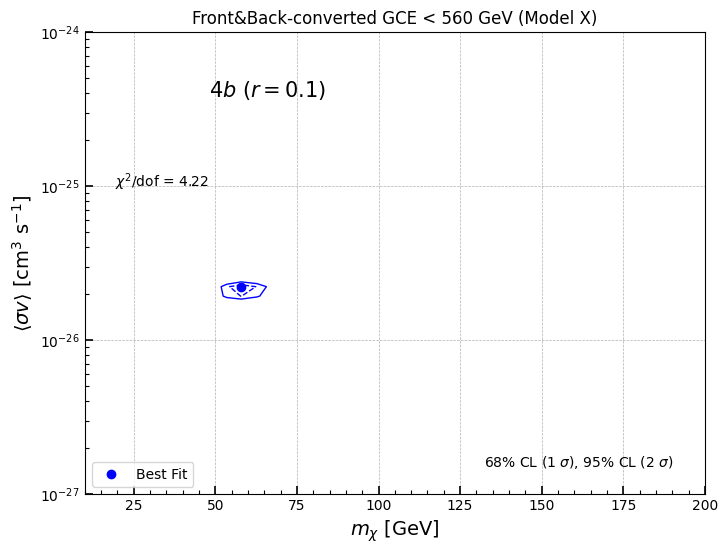

In [3]:
# Model I Covariance matrix used of 4b (Cascade) case chi-squared contour plot r0.1

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
import warnings
import os

# 🔥 핵심 마법: 파일 데이터를 저장해둘 전역 딕셔너리 (캐시)
_CASCADE_CACHE = {}

def get_cascade_spectrum(mass, channel_file, eps_f=0.01):
    """
    Cascade Spectra 라이브러리에서 4-body 스펙트럼을 로드합니다.
    """
    if channel_file not in _CASCADE_CACHE:
        possible_paths = ['./CascadeSpectra/Spectra', './', '/home/haebarg/ipynb/Spectra/']
        full_path = None
        
        for p in possible_paths:
            test_path = os.path.join(p, channel_file)
            if os.path.exists(test_path):
                full_path = test_path
                break
                
        if full_path is None:
            raise FileNotFoundError(f"Cannot find Cascade file: {channel_file}. 'Spectra' 폴더를 확인해주세요.")

        try:
            with open(full_path, 'r') as f:
                lines = (line for line in f if not line.startswith('#'))
                _CASCADE_CACHE[channel_file] = np.genfromtxt(lines, names=True, dtype=None)
        except Exception as e:
            print(f"Error loading {full_path}: {e}")
            return None, None

    data = _CASCADE_CACHE[channel_file]

    epsvals = data["EpsF"]
    available_eps = np.unique(epsvals)
    closest_eps = available_eps[np.argmin(np.abs(available_eps - eps_f))]
    index = np.where(epsvals == closest_eps)
    
    if len(index[0]) == 0:
        raise ValueError(f"Epsilon_f = {eps_f} not found in file.")

    log10x = data["Log10x"][index]
    x_vals = 10**log10x

    dNdlog10x = data["n1"][index] 
    dNdx = dNdlog10x / (np.log(10) * x_vals)
    
    interp_func = interp1d(x_vals, dNdx, kind='linear', bounds_error=False, fill_value=0.0)
    energy_axis = np.logspace(np.log10(1e-6 * mass), np.log10(mass), 500)
    x_target = energy_axis / mass
    
    dNdx_vals = interp_func(x_target)
    dNdE = dNdx_vals / mass
    dNdE = np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)
    dNdE[dNdE < 0] = 0.0
    
    return energy_axis, dNdE

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
cascade_filename = 'Cascade_B_gammas.dat'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

# =======================================================
# 📌 여기에 r_ratio와 m_b를 정의합니다! (전역 변수로 설정)
# r=0.1 로 바꾸고 싶으시면 여기서 바로 숫자만 고치시면 됩니다.
# =======================================================
r_ratio = 0.1
m_b = 4.18

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model} ({channel_name}, r={r_ratio})...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                
                # 위에서 정의한 전역 변수를 그대로 가져다 씁니다.
                dynamic_eps_f = (2 * m_b) / (r_ratio * dm_mass)
                
                energy_axis, dNdE_vals = get_cascade_spectrum(dm_mass, cascade_filename, eps_f=dynamic_eps_f)
                
                func_interp = interp1d(energy_axis, dNdE_vals, 
                                     fill_value=0, bounds_error=False, kind='linear')
                
                dNdE_interp = func_interp(emeans)
                model_flux = (emeans**2) * dNdE_interp * (sigma_v/(dm_mass**2)) * J_FACTOR / SR
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)

            chi_square_vec = np.vectorize(chi_square)

            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -24, 50) 
            mass_range = np.logspace(np.log10(10), np.log10(500), 50) 
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            levels = [min_chi2 + 2.30, min_chi2 + 6.18] 

            plt.figure(figsize=(8, 6))
            
            try:
                CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                            levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)

            except:
                print("⚠️ Contour generation failed (level issue potentially).")
                pass

            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2 / dof), 
                transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'$4b$ ($r={}$)'.format(r_ratio), transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GCE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_r{r_ratio}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X (4b, r=0.5)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_14_4b_r0.5_16yr.png


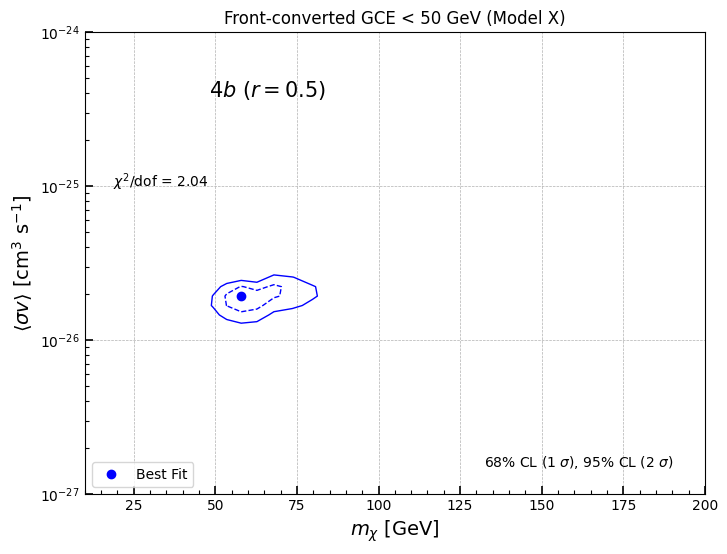

Processing: front, 17 bins, Model X (4b, r=0.5)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_E_17_4b_r0.5_16yr.png


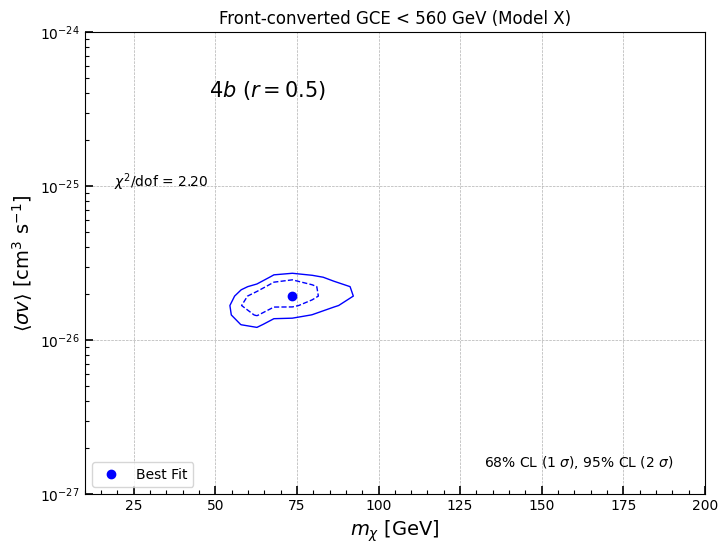

Processing: front_back, 14 bins, Model X (4b, r=0.5)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_14_4b_r0.5_16yr.png


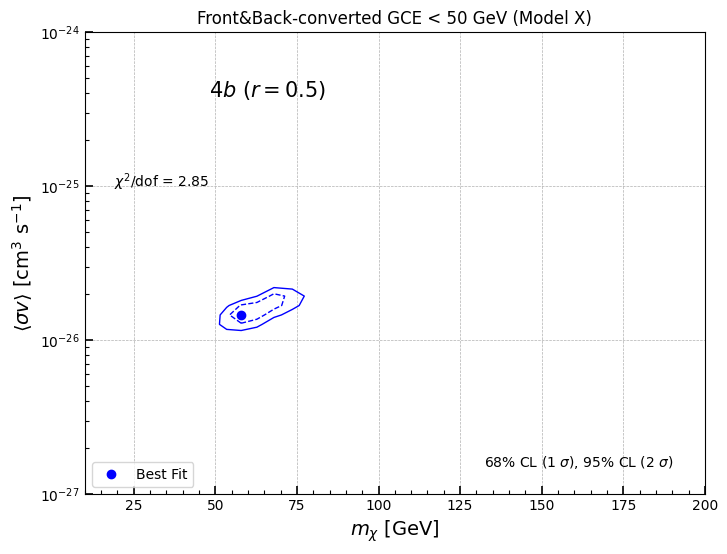

Processing: front_back, 17 bins, Model X (4b, r=0.5)...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GCE_model_X_front_back_E_17_4b_r0.5_16yr.png


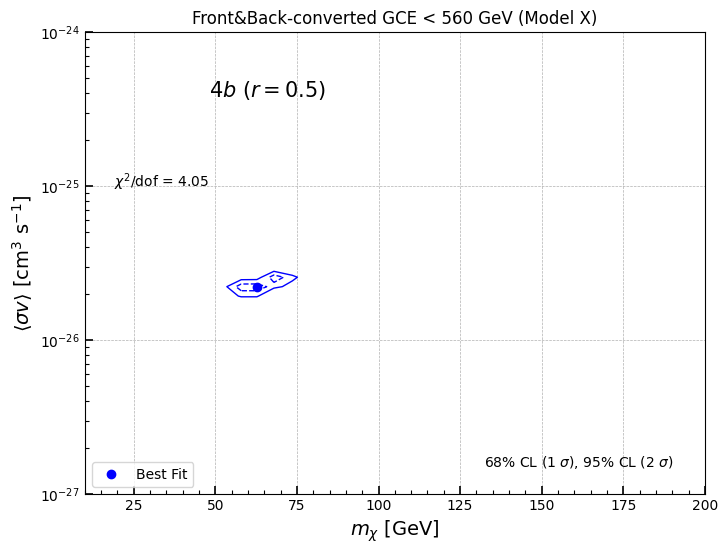

In [4]:
# Model I Covariance matrix used of 4b (Cascade) case chi-squared contour plot r0.5

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
import warnings
import os

# 🔥 핵심 마법: 파일 데이터를 저장해둘 전역 딕셔너리 (캐시)
_CASCADE_CACHE = {}

def get_cascade_spectrum(mass, channel_file, eps_f=0.01):
    """
    Cascade Spectra 라이브러리에서 4-body 스펙트럼을 로드합니다.
    """
    if channel_file not in _CASCADE_CACHE:
        possible_paths = ['./CascadeSpectra/Spectra', './', '/home/haebarg/ipynb/Spectra/']
        full_path = None
        
        for p in possible_paths:
            test_path = os.path.join(p, channel_file)
            if os.path.exists(test_path):
                full_path = test_path
                break
                
        if full_path is None:
            raise FileNotFoundError(f"Cannot find Cascade file: {channel_file}. 'Spectra' 폴더를 확인해주세요.")

        try:
            with open(full_path, 'r') as f:
                lines = (line for line in f if not line.startswith('#'))
                _CASCADE_CACHE[channel_file] = np.genfromtxt(lines, names=True, dtype=None)
        except Exception as e:
            print(f"Error loading {full_path}: {e}")
            return None, None

    data = _CASCADE_CACHE[channel_file]

    epsvals = data["EpsF"]
    available_eps = np.unique(epsvals)
    closest_eps = available_eps[np.argmin(np.abs(available_eps - eps_f))]
    index = np.where(epsvals == closest_eps)
    
    if len(index[0]) == 0:
        raise ValueError(f"Epsilon_f = {eps_f} not found in file.")

    log10x = data["Log10x"][index]
    x_vals = 10**log10x

    dNdlog10x = data["n1"][index] 
    dNdx = dNdlog10x / (np.log(10) * x_vals)
    
    interp_func = interp1d(x_vals, dNdx, kind='linear', bounds_error=False, fill_value=0.0)
    energy_axis = np.logspace(np.log10(1e-6 * mass), np.log10(mass), 500)
    x_target = energy_axis / mass
    
    dNdx_vals = interp_func(x_target)
    dNdE = dNdx_vals / mass
    dNdE = np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)
    dNdE[dNdE < 0] = 0.0
    
    return energy_axis, dNdE

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
cascade_filename = 'Cascade_B_gammas.dat'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

# =======================================================
# 📌 여기에 r_ratio와 m_b를 정의합니다! (전역 변수로 설정)
# r=0.1 로 바꾸고 싶으시면 여기서 바로 숫자만 고치시면 됩니다.
# =======================================================
r_ratio = 0.5
m_b = 4.18

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model} ({channel_name}, r={r_ratio})...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                
                # 위에서 정의한 전역 변수를 그대로 가져다 씁니다.
                dynamic_eps_f = (2 * m_b) / (r_ratio * dm_mass)
                
                energy_axis, dNdE_vals = get_cascade_spectrum(dm_mass, cascade_filename, eps_f=dynamic_eps_f)
                
                func_interp = interp1d(energy_axis, dNdE_vals, 
                                     fill_value=0, bounds_error=False, kind='linear')
                
                dNdE_interp = func_interp(emeans)
                model_flux = (emeans**2) * dNdE_interp * (sigma_v/(dm_mass**2)) * J_FACTOR / SR
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)

            chi_square_vec = np.vectorize(chi_square)

            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -24, 50) 
            mass_range = np.logspace(np.log10(10), np.log10(500), 50) 
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            levels = [min_chi2 + 2.30, min_chi2 + 6.18] 

            plt.figure(figsize=(8, 6))
            
            try:
                CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                            levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)

            except:
                print("⚠️ Contour generation failed (level issue potentially).")
                pass

            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2 / dof), 
                transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'$4b$ ($r={}$)'.format(r_ratio), transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GCE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_r{r_ratio}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

In [ ]:
# r=0.3,0.1등의 case는 공식상 epsilon_f의 값이 0.5 이상으로 치솟는데,
# 이 라이브러리가 현재 제공하는 epsilon_f의 범위는 0.01~0.5이므로 비교가 불가능.
# large hirarchy approximation의 영향을 덜 받으면서도 이 라이브러리의 spectra를 활용하는 한계는 r0.5정도인듯.
# r0.5의 경우 bestfit point나 주변 범위가 달라지는 경우는 있으나 유사한 편이고, chi-square 값은 거의 같음.